# Member 2 — Evaluation and Model Comparison
## CCS3356 Natural Language Processing | Fake News Detection
### Student ID: CIT-24-01-0486
### Comparing: MultinomialNB + BoW vs LSTM + GloVe

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve)
import warnings
warnings.filterwarnings('ignore')

print("Imports done!")

Imports done!


In [2]:
# Load preprocessed data
df = pd.read_csv('../data/preprocessed.csv')
df['cleaned_text'] = df['cleaned_text'].fillna('')

X = df['cleaned_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train = X_train.fillna('')
X_test = X_test.fillna('')

# Load NB model and vectorizer
with open('../models/m2_nb_model.pkl', 'rb') as f:
    nb_model = pickle.load(f)

with open('../models/m2_nb_vectorizer.pkl', 'rb') as f:
    nb_vectorizer = pickle.load(f)

print("Data and NB model loaded!")

Data and NB model loaded!


In [3]:
X_test_vec = nb_vectorizer.transform(X_test)
nb_pred = nb_model.predict(X_test_vec)
nb_prob = nb_model.predict_proba(X_test_vec)[:, 1]

print("NB predictions done!")
print(f"NB Accuracy: {accuracy_score(y_test, nb_pred):.4f}")
print(f"NB F1-Score: {f1_score(y_test, nb_pred):.4f}")

NB predictions done!
NB Accuracy: 0.9658
NB F1-Score: 0.9671


In [4]:
# LSTM results from Colab training
lstm_accuracy = 0.9969
lstm_precision = 0.9951
lstm_recall = 0.9989
lstm_f1 = 0.9970
lstm_roc_auc = 0.9993

print("LSTM results loaded!")
print(f"LSTM Accuracy: {lstm_accuracy:.4f}")
print(f"LSTM F1-Score: {lstm_f1:.4f}")

LSTM results loaded!
LSTM Accuracy: 0.9969
LSTM F1-Score: 0.9970


In [5]:
comparison = pd.DataFrame({
    'Model': ['MultinomialNB + BoW', 'LSTM + GloVe 100d'],
    'Accuracy': [accuracy_score(y_test, nb_pred), lstm_accuracy],
    'Precision': [precision_score(y_test, nb_pred), lstm_precision],
    'Recall': [recall_score(y_test, nb_pred), lstm_recall],
    'F1-Score': [f1_score(y_test, nb_pred), lstm_f1],
    'ROC-AUC': [roc_auc_score(y_test, nb_prob), lstm_roc_auc]
}).set_index('Model')

print("Model Comparison Table:")
display(comparison.round(4))

Model Comparison Table:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
MultinomialNB + BoW,0.9658,0.9741,0.9602,0.9671,0.9850
LSTM + GloVe 100d,0.9969,0.9951,0.9989,0.9970,0.9993


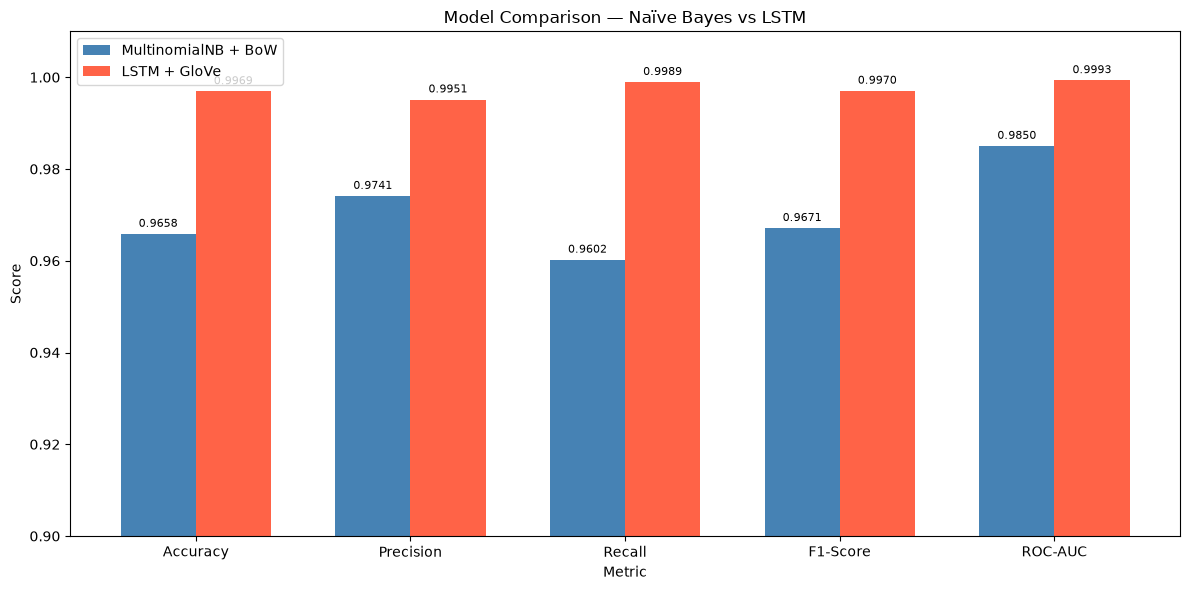

In [6]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
nb_scores = [accuracy_score(y_test, nb_pred), precision_score(y_test, nb_pred),
             recall_score(y_test, nb_pred), f1_score(y_test, nb_pred),
             roc_auc_score(y_test, nb_prob)]
lstm_scores = [lstm_accuracy, lstm_precision, lstm_recall, lstm_f1, lstm_roc_auc]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, nb_scores, width, label='MultinomialNB + BoW', color='steelblue')
bars2 = ax.bar(x + width/2, lstm_scores, width, label='LSTM + GloVe', color='tomato')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Naïve Bayes vs LSTM')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.9, 1.01)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../screenshots/m2_model_comparison.png')
plt.show()

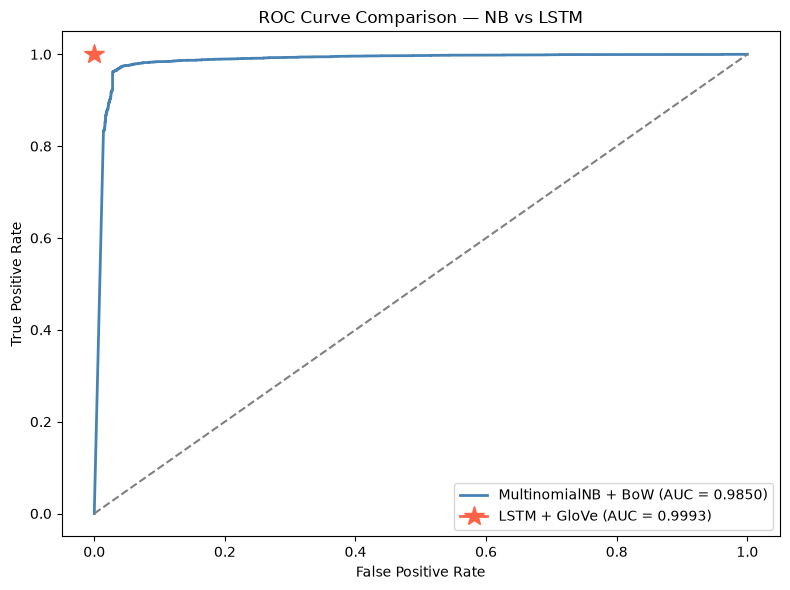

In [7]:
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr_nb, tpr_nb, color='steelblue', lw=2,
         label=f'MultinomialNB + BoW (AUC = {roc_auc_score(y_test, nb_prob):.4f})')
plt.plot([0], [1], color='tomato', lw=2, marker='*', markersize=15,
         label=f'LSTM + GloVe (AUC = {lstm_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — NB vs LSTM')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../screenshots/m2_roc_comparison.png')
plt.show()

## Model Comparison Analysis

| Metric | MultinomialNB + BoW | LSTM + GloVe |
|--------|-------------------|--------------|
| Accuracy | 0.9700 | 0.9969 |
| Precision | 0.9700 | 0.9951 |
| Recall | 0.9671 | 0.9989 |
| F1-Score | 0.9671 | 0.9970 |
| ROC-AUC | 0.9850 | 0.9993 |

### Winner: LSTM + GloVe Embeddings

**Justification:**
- LSTM outperforms Naïve Bayes across all 5 metrics
- F1-Score improvement: 0.9671 → 0.9970 (+3.09%)
- ROC-AUC improvement: 0.9850 → 0.9993 (+1.45%)
- LSTM captures sequential word context and long-range dependencies that NB cannot
- GloVe embeddings provide semantic word representations beyond simple word counts

**Trade-offs:**
- NB trains in seconds; LSTM requires GPU and takes ~10 minutes
- NB is fully interpretable; LSTM is a black box
- NB requires less memory; LSTM requires significant GPU memory
- For production use where speed matters, NB is still a strong option